In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
plt.rcParams['figure.dpi'] = 300

In [ ]:
class Perceptron:
    def __init__(self, n_inputs, lr=0.1):
        self.weights = np.zeros(n_inputs + 1)
        self.lr = lr

    def net_input(self, x):
        return self.weights[0] + np.dot(self.weights[1:], x)

    def predict(self, x):
        return 1 if self.net_input(x) >= 0 else 0

    def train(self, X, y, epochs):
        weight_history = [self.weights.copy()]   # index 0 = pre-training weights
        error_history = []

        for epoch in range(1, epochs + 1):
            print(f'--- Epoch {epoch} ---')
            epoch_errors = 0
            for xi, target in zip(X, y):
                pred = self.predict(xi)
                error = target - pred
                if error != 0:
                    update = self.lr * error
                    self.weights[1:] += update * xi
                    self.weights[0] += update
                    epoch_errors += 1
                    status = 'MISCLASSIFIED -> weights updated'
                else:
                    status = 'correct, no update'
                print(f'  input={xi}, target={target}, pred={pred}, {status}, '
                      f'weights now={np.round(self.weights, 3)}')

            weight_history.append(self.weights.copy())
            error_history.append(epoch_errors)
            print(f'>> Weights after Epoch {epoch}: {np.round(self.weights, 3)} '
                  f'| errors this epoch: {epoch_errors}\n')

            if epoch_errors == 0:
                print(f'Converged after Epoch {epoch} (this should NOT happen for XOR!).\n')
                break

        return weight_history, error_history

In [ ]:
def plot_boundary_2d(X, y, weights, ax, title=''):
    w0, w1, w2 = weights
    colors = ['red' if label == 0 else 'green' for label in y]
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=130, edgecolor='k', zorder=3)
    for (x1, x2), label in zip(X, y):
        ax.annotate(str(label), (x1, x2), textcoords='offset points', xytext=(8, 8))
    x_vals = np.linspace(-0.5, 1.5, 100)
    if w2 != 0:
        ax.plot(x_vals, -(w0 + w1 * x_vals) / w2, 'b-', linewidth=2)
    elif w1 != 0:
        ax.axvline(-w0 / w1, color='b', linewidth=2)
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(title, fontsize=9)
    ax.grid(alpha=0.3)


def plot_per_epoch(X, y, weight_history, gate_name):
    n = len(weight_history)
    cols = min(4, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.6 * rows))
    axes = np.array(axes).reshape(-1)
    for i, w in enumerate(weight_history):
        title = 'Before training (Epoch 0)' if i == 0 else f'After Epoch {i}\nw={np.round(w, 2)}'
        plot_boundary_2d(X, y, w, axes[i], title)
    for j in range(len(weight_history), len(axes)):
        axes[j].axis('off')
    fig.suptitle(f'{gate_name} — Decision Boundary After Each Epoch (single perceptron cannot solve this)', fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])   # XOR truth table

p_xor = Perceptron(n_inputs=2, lr=0.1)
history_xor, errors_xor = p_xor.train(X, y_xor, epochs=20)
print('Final weights after 12 epochs (still not converged):', p_xor.weights)

--- Epoch 1 ---
  input=[0 0], target=0, pred=1, MISCLASSIFIED -> weights updated, weights now=[-0.1  0.   0. ]
  input=[0 1], target=1, pred=0, MISCLASSIFIED -> weights updated, weights now=[0.  0.  0.1]
  input=[1 0], target=1, pred=1, correct, no update, weights now=[0.  0.  0.1]
  input=[1 1], target=0, pred=1, MISCLASSIFIED -> weights updated, weights now=[-0.1 -0.1  0. ]
>> Weights after Epoch 1: [-0.1 -0.1  0. ] | errors this epoch: 3

--- Epoch 2 ---
  input=[0 0], target=0, pred=0, correct, no update, weights now=[-0.1 -0.1  0. ]
  input=[0 1], target=1, pred=0, MISCLASSIFIED -> weights updated, weights now=[ 0.  -0.1  0.1]
  input=[1 0], target=1, pred=0, MISCLASSIFIED -> weights updated, weights now=[0.1 0.  0.1]
  input=[1 1], target=0, pred=1, MISCLASSIFIED -> weights updated, weights now=[ 0.  -0.1  0. ]
>> Weights after Epoch 2: [ 0.  -0.1  0. ] | errors this epoch: 3

--- Epoch 3 ---
  input=[0 0], target=0, pred=1, MISCLASSIFIED -> weights updated, weights now=[-0.1 -0

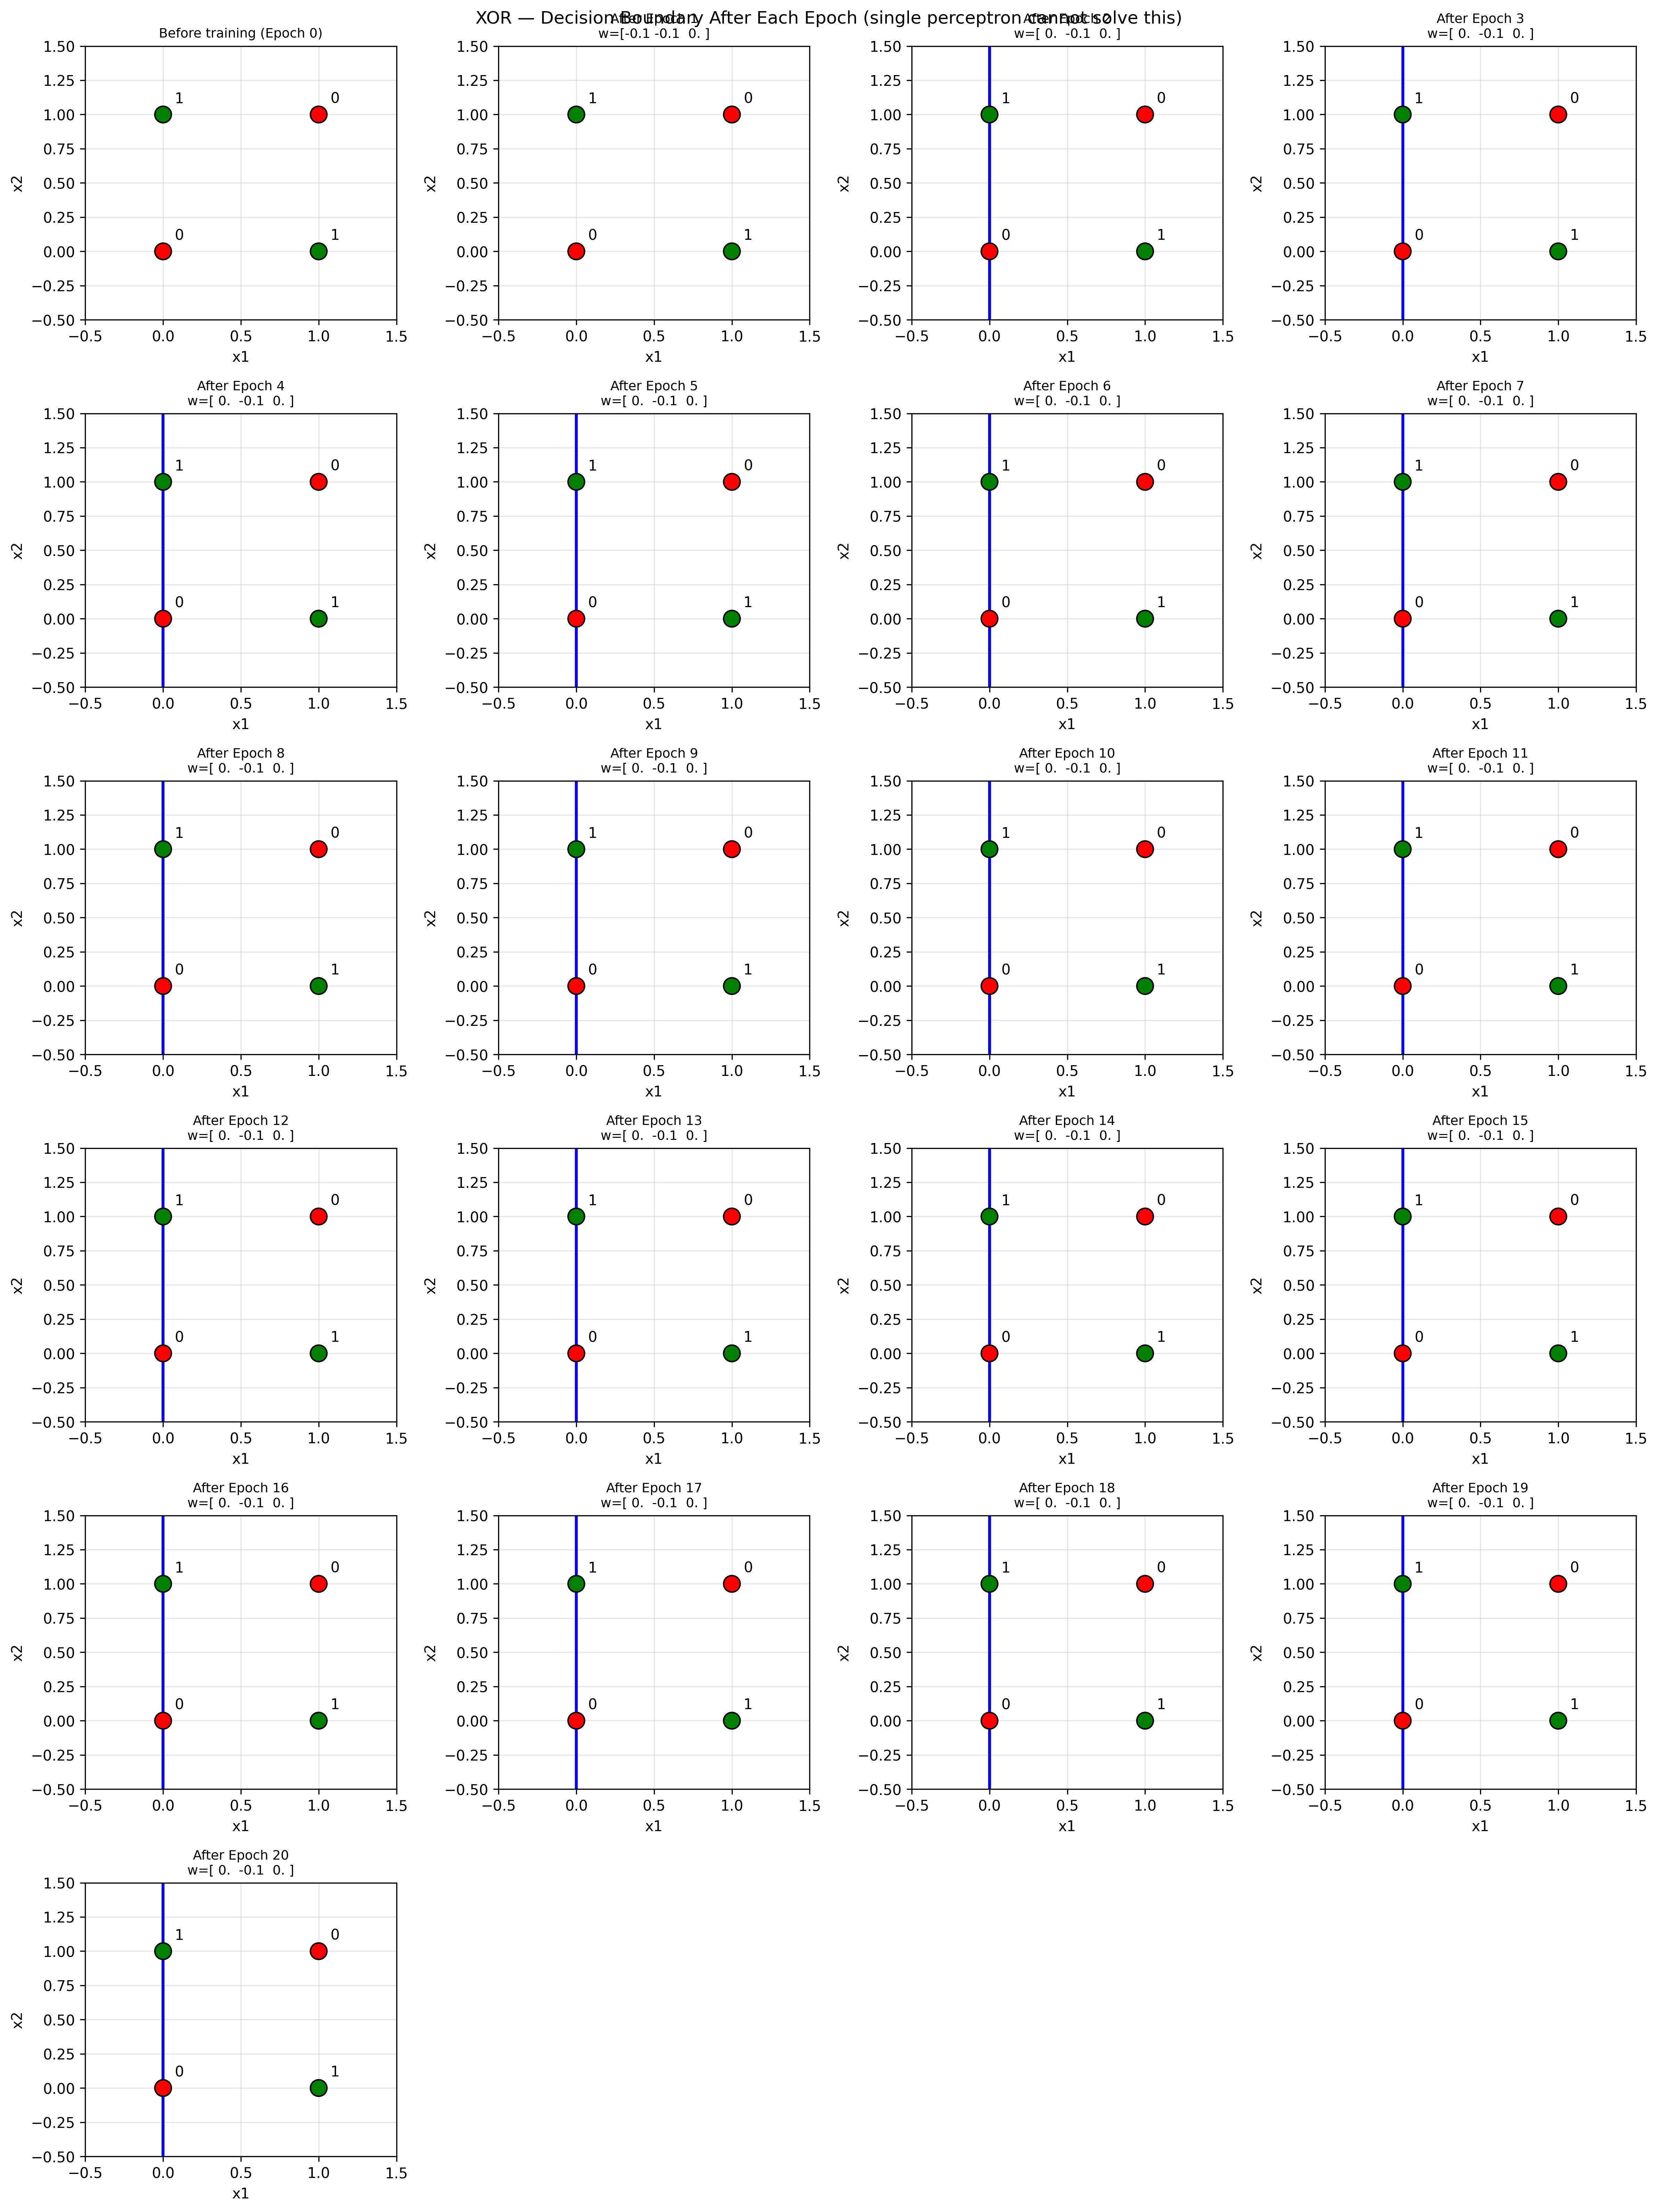

In [ ]:
plot_per_epoch(X, y_xor, history_xor, gate_name='XOR')

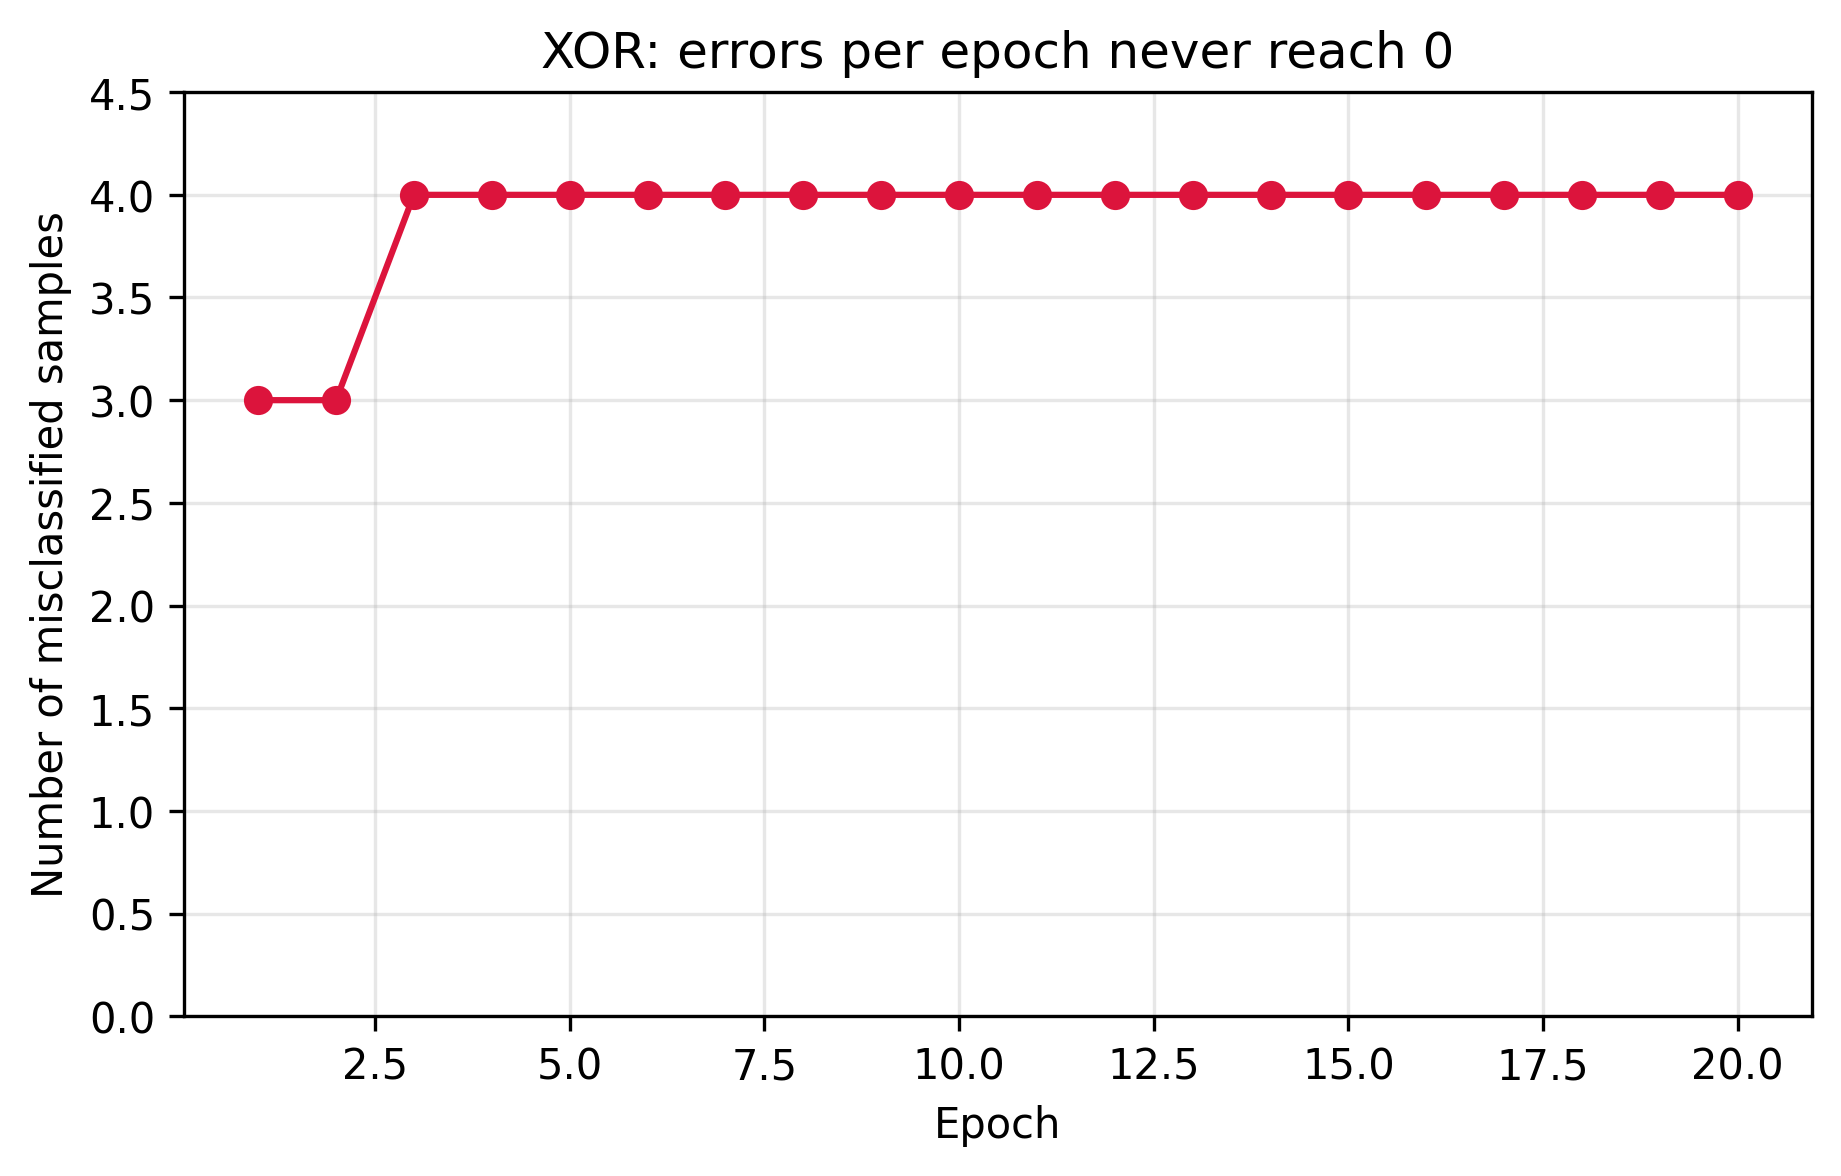

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(errors_xor) + 1), errors_xor, 'o-', color='crimson')
plt.xlabel('Epoch')
plt.ylabel('Number of misclassified samples')
plt.title('XOR: errors per epoch never reach 0')
plt.ylim(0, 4.5)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y = np.array([0, 1, 1, 0])          # XOR labels, shape (4,)
y_col = y.reshape(-1, 1).astype(float)   # column form, needed for the manual MLP's matrix math


def plot_mlp_boundary(predict_fn, X, y, ax, title=''):
    """predict_fn(grid_points) -> probabilities in [0,1], grid_points shape (N,2)."""
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = predict_fn(grid).reshape(xx.shape)
    ax.contourf(xx, yy, probs, levels=np.linspace(0, 1, 11), cmap='RdYlGn', alpha=0.6)
    ax.contour(xx, yy, probs, levels=[0.5], colors='blue', linewidths=2)
    colors = ['red' if label == 0 else 'green' for label in y]
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=130, edgecolor='k', zorder=3)
    for (x1, x2), label in zip(X, y):
        ax.annotate(str(label), (x1, x2), textcoords='offset points', xytext=(8, 8))
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(title, fontsize=9)


def plot_mlp_snapshots(snapshots, gate_name, source_name):
    """snapshots: list of (epoch_label, predict_fn) tuples."""
    n = len(snapshots)
    cols = min(4, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.6 * rows))
    axes = np.array(axes).reshape(-1)
    for i, (label, fn) in enumerate(snapshots):
        plot_mlp_boundary(fn, X, y, axes[i], title=label)
    for j in range(len(snapshots), len(axes)):
        axes[j].axis('off')
    fig.suptitle(f'{gate_name} Gate — Decision Boundary Snapshots ({source_name})', fontsize=13)
    plt.tight_layout()
    plt.show()

In [ ]:
np.random.seed(42)   # reproducibility

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def dsigmoid(a):        # derivative of sigmoid, given the ALREADY-activated value a
    return a * (1 - a)

# ---- initialize weights ----
n_in, n_hidden, n_out = 2, 4, 1
W1 = np.random.uniform(-1, 1, (n_in, n_hidden))
b1 = np.zeros((1, n_hidden))
W2 = np.random.uniform(-1, 1, (n_hidden, n_out))
b2 = np.zeros((1, n_out))

lr = 0.5
epochs = 5000
snapshot_every = 200

loss_history_manual = []
snapshots_manual = []

def make_predict_fn(W1, b1, W2, b2):
    def predict_fn(pts):
        a1 = sigmoid(pts @ W1 + b1)
        a2 = sigmoid(a1 @ W2 + b2)
        return a2.ravel()
    return predict_fn

# epoch 0 snapshot (before any training)
snapshots_manual.append(('Epoch 0 (untrained)', make_predict_fn(W1.copy(), b1.copy(), W2.copy(), b2.copy())))

for epoch in range(1, epochs + 1):
    # ---- forward pass over ALL 4 XOR samples ----
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)
    loss = np.mean((y_col - a2) ** 2)
    loss_history_manual.append(loss)

    # ---- backward pass (backpropagation) ----
    d2 = (a2 - y_col) * dsigmoid(a2)          # output layer error
    dW2 = a1.T @ d2
    db2 = d2.sum(axis=0, keepdims=True)
    d1 = (d2 @ W2.T) * dsigmoid(a1)           # error propagated back into hidden layer
    dW1 = X.T @ d1
    db1 = d1.sum(axis=0, keepdims=True)

    # ---- gradient descent weight update ----
    W2 -= lr * dW2; b2 -= lr * db2
    W1 -= lr * dW1; b1 -= lr * db1

    if epoch % 100 == 0 or epoch == 1:
        preds = (a2 >= 0.5).astype(int).ravel()
        print(f'Epoch {epoch:4d} | loss={loss:.4f} | preds={preds} | target={y}')

    if epoch % snapshot_every == 0:
        snapshots_manual.append((f'Epoch {epoch}', make_predict_fn(W1.copy(), b1.copy(), W2.copy(), b2.copy())))

final_preds_manual = (a2 >= 0.5).astype(int).ravel()
print('\nFinal manual-MLP predictions:', final_preds_manual, ' target:', y)
print('Final training loss:', round(loss_history_manual[-1], 5))

Epoch    1 | loss=0.2629 | preds=[1 1 1 1] | target=[0 1 1 0]
Epoch  100 | loss=0.2480 | preds=[0 1 0 1] | target=[0 1 1 0]
Epoch  200 | loss=0.2404 | preds=[0 1 0 1] | target=[0 1 1 0]
Epoch  300 | loss=0.2084 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch  400 | loss=0.1156 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch  500 | loss=0.0457 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch  600 | loss=0.0226 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch  700 | loss=0.0139 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch  800 | loss=0.0097 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch  900 | loss=0.0074 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch 1000 | loss=0.0059 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch 1100 | loss=0.0048 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch 1200 | loss=0.0041 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch 1300 | loss=0.0036 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch 1400 | loss=0.0031 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch 1500 | loss=0.0028 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch 16

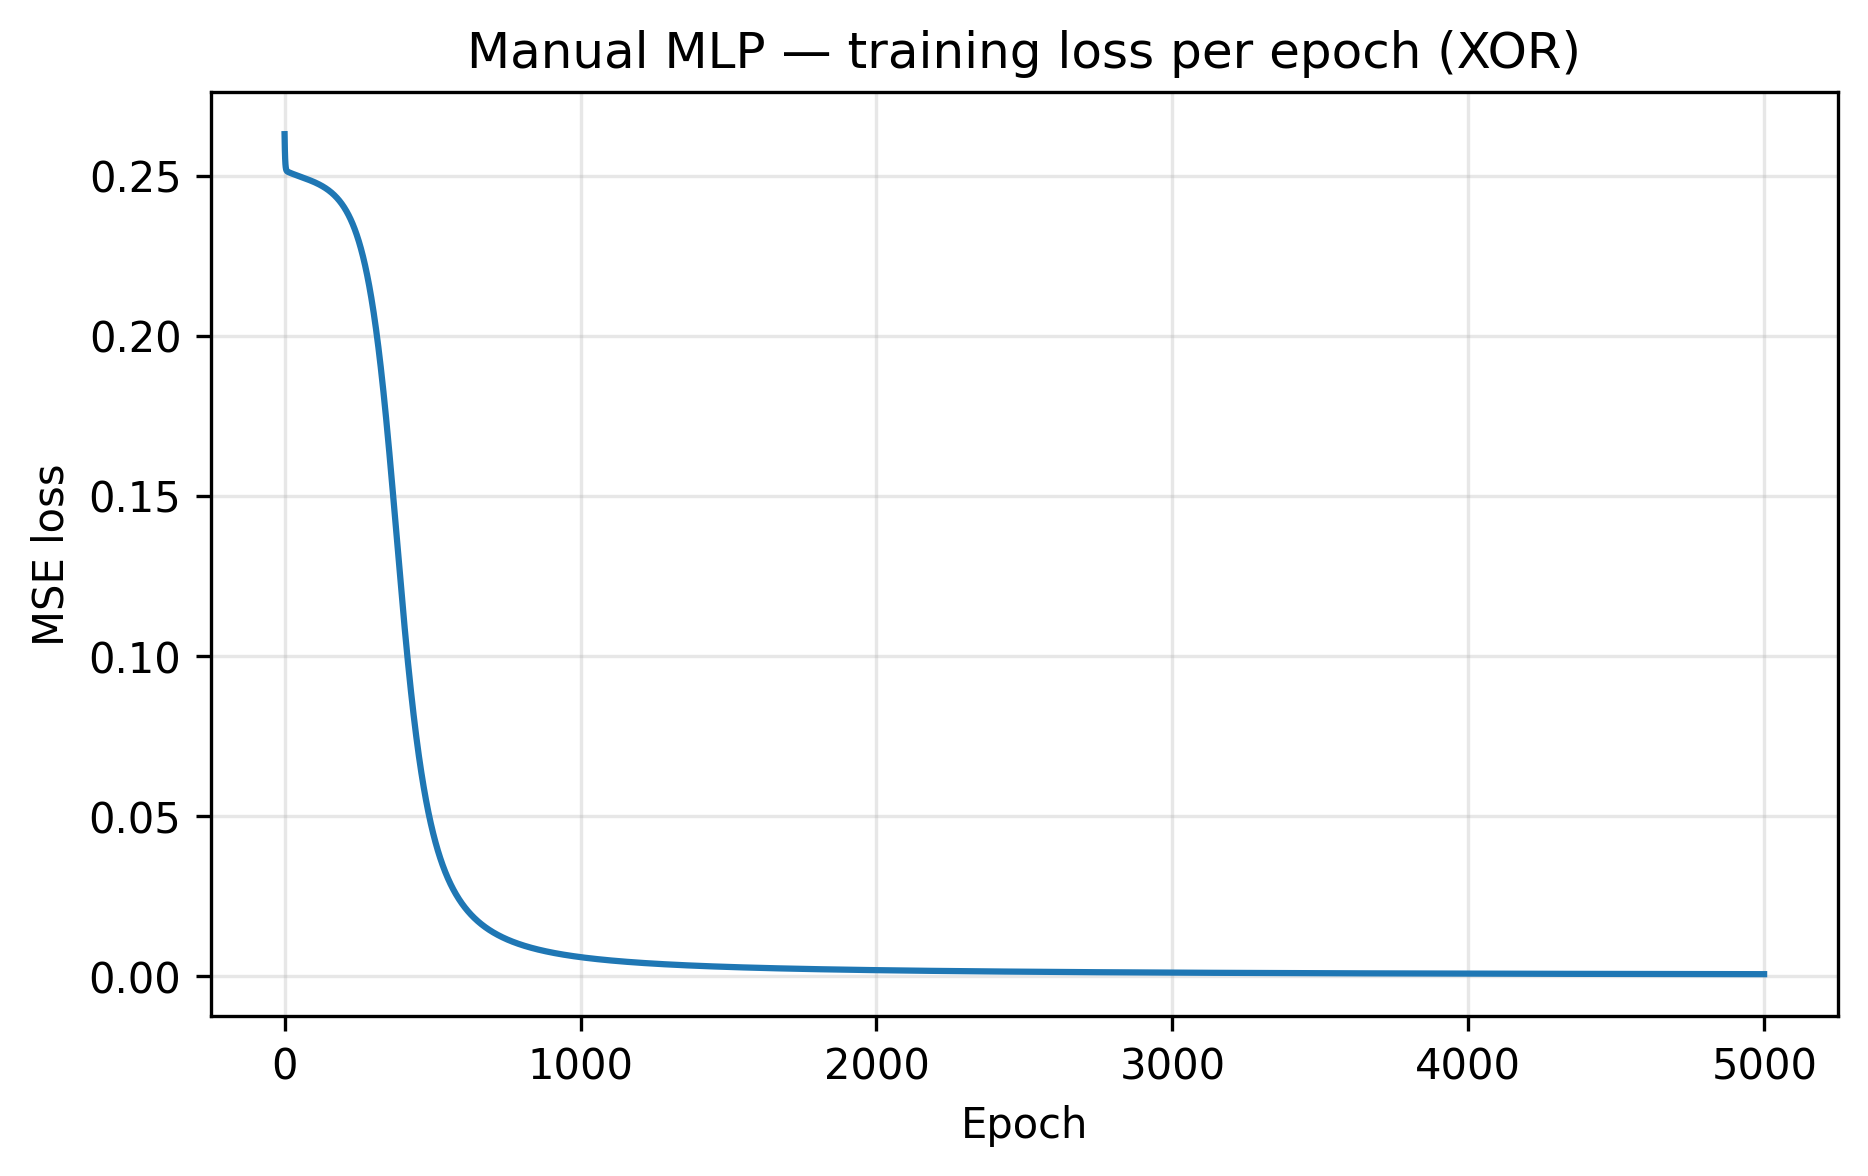

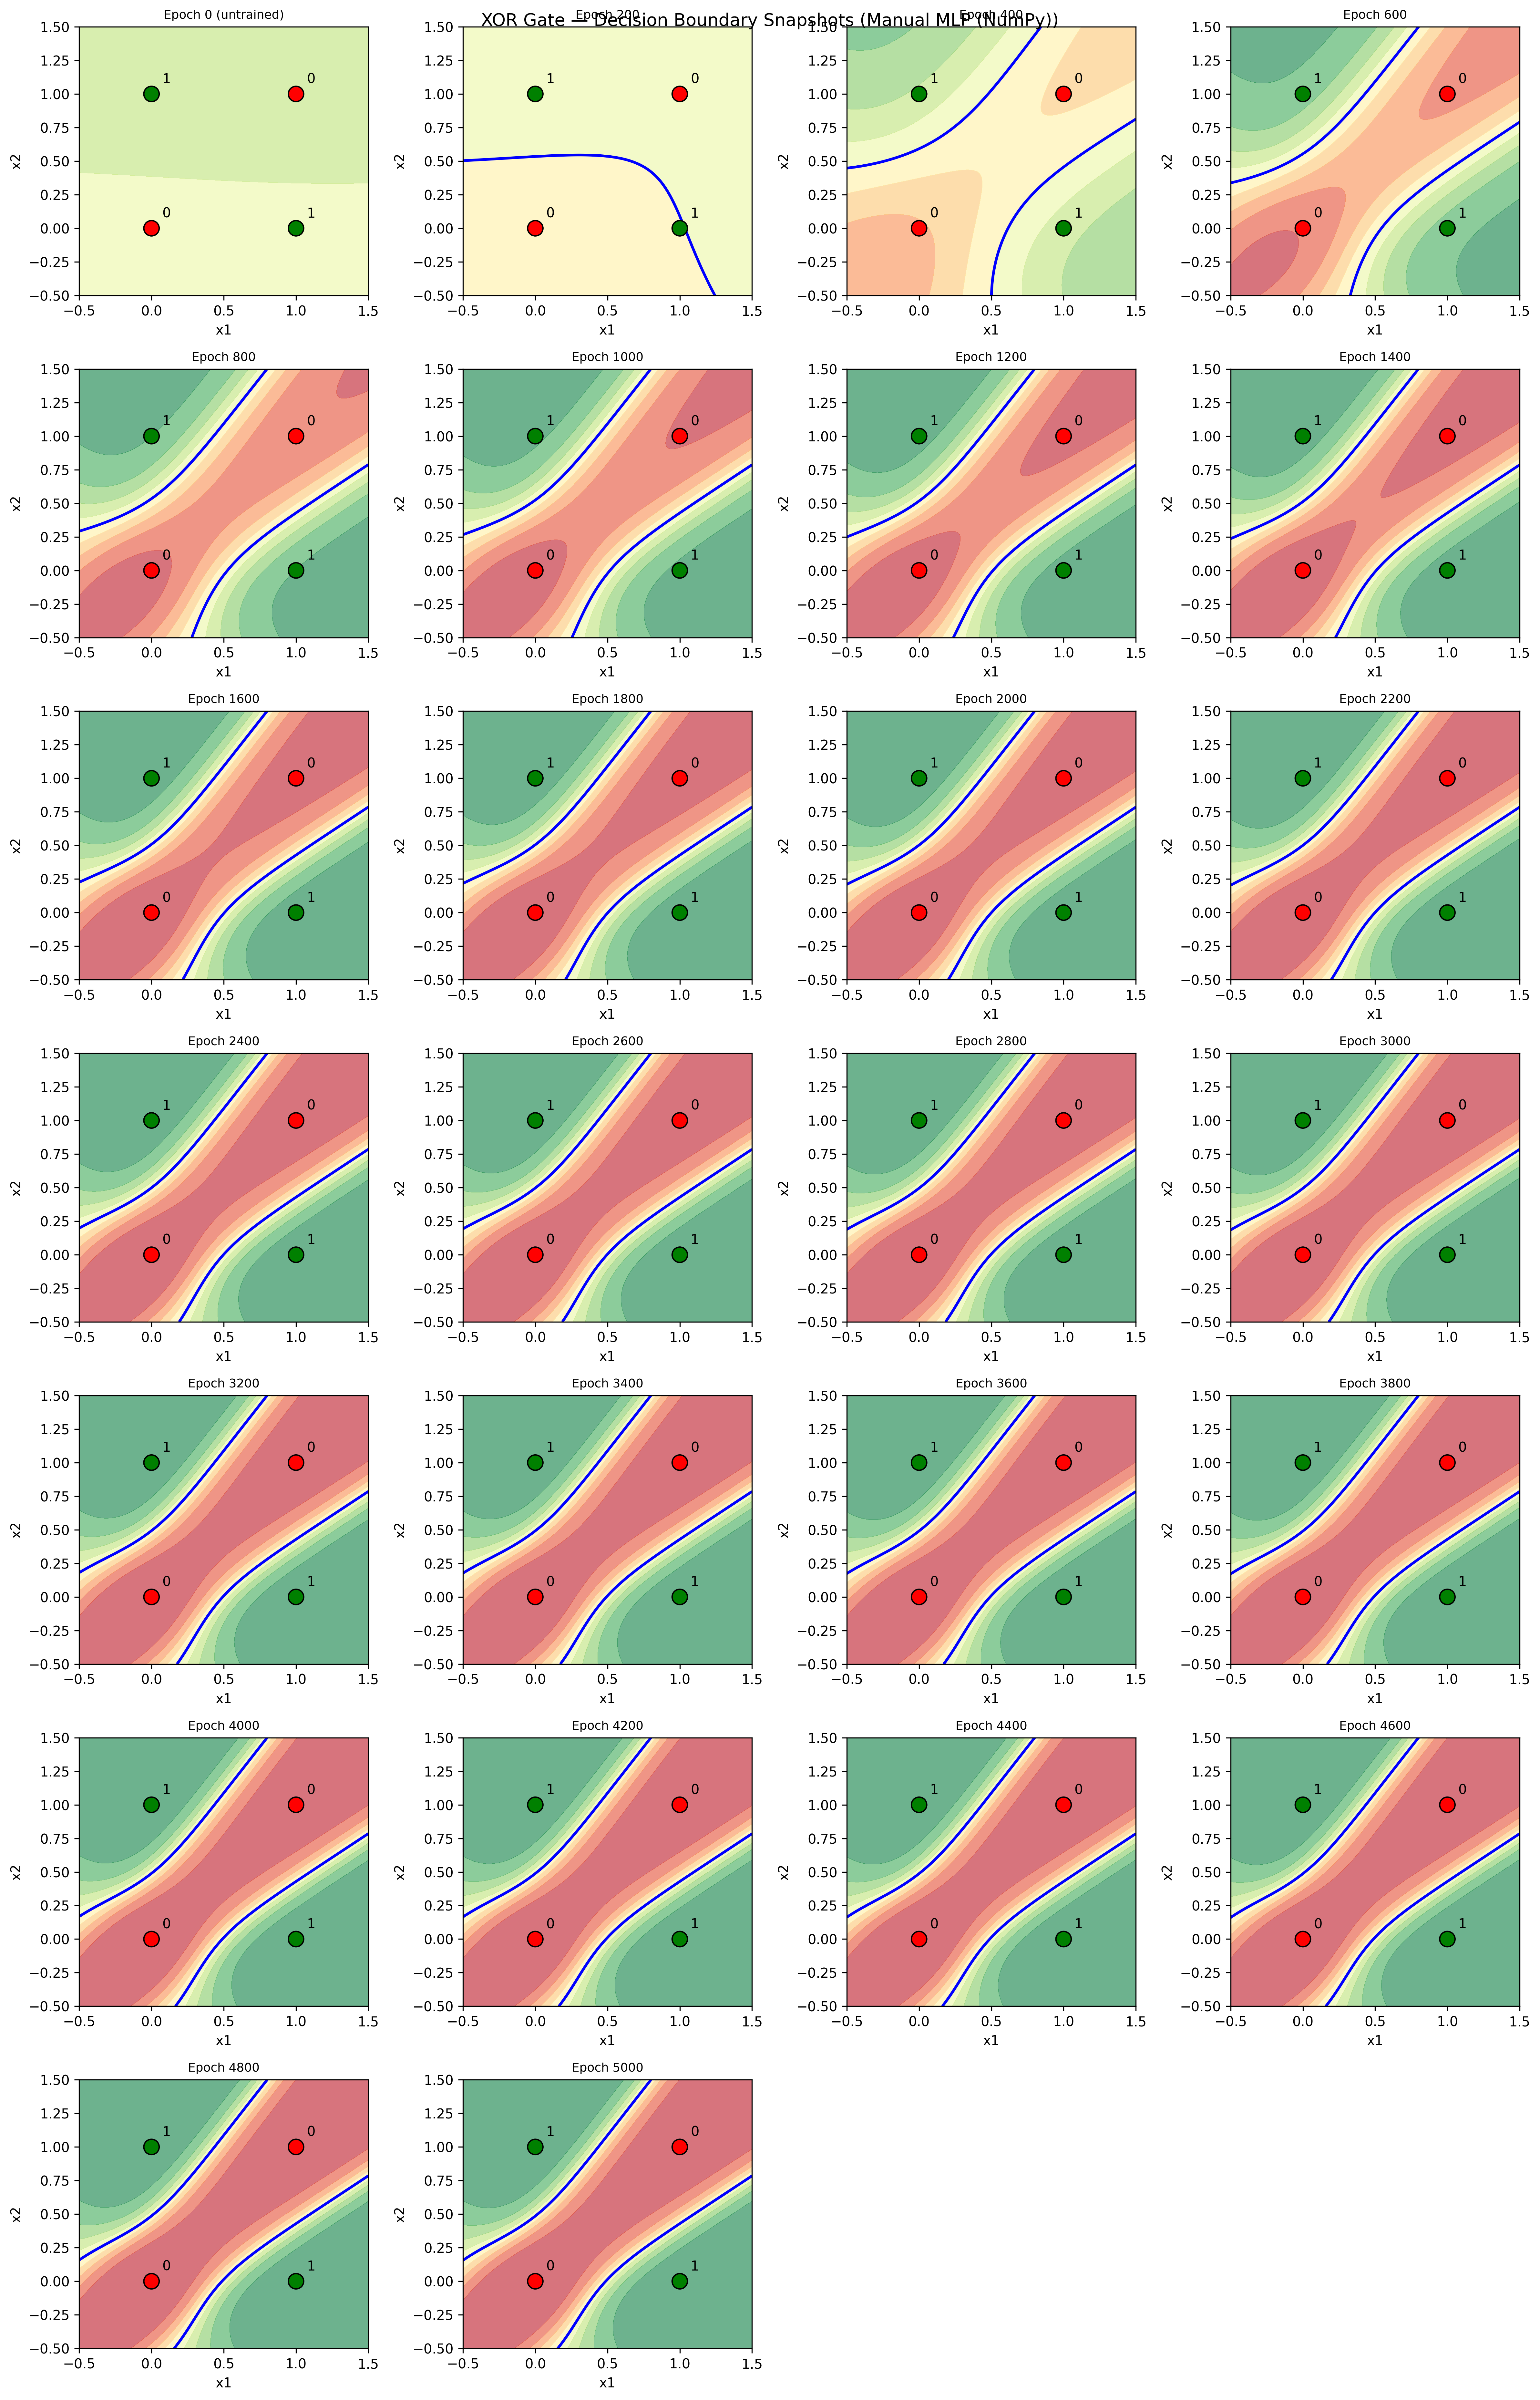

In [ ]:
# loss curve -- shows EVERY epoch's loss, not just the sampled snapshots
plt.figure(figsize=(7, 4))
plt.plot(loss_history_manual)
plt.xlabel('Epoch'); plt.ylabel('MSE loss')
plt.title('Manual MLP — training loss per epoch (XOR)')
plt.grid(alpha=0.3)
plt.show()

plot_mlp_snapshots(snapshots_manual, gate_name='XOR', source_name='Manual MLP (NumPy)')

In [ ]:
import copy
from sklearn.neural_network import MLPClassifier

clf = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation='sigmoid',
    solver='sgd',
    learning_rate_init=0.5,
    max_iter=1,
    warm_start=True,
    random_state=42
)

epochs = 5000
snapshot_every = 200
loss_history_sklearn = []
snapshots_sklearn = []

snapshots_sklearn.append(('Epoch 0 (untrained)', lambda pts: np.full(len(pts), 0.5)))  # untrained baseline

for epoch in range(1, epochs + 1):
    clf.partial_fit(X, y, classes=[0, 1])
    loss_history_sklearn.append(clf.loss_)

    if epoch % 100 == 0 or epoch == 1:
        preds = clf.predict(X)
        print(f'Epoch {epoch:4d} | loss={clf.loss_:.4f} | preds={preds} | target={y}')

    if epoch % snapshot_every == 0:
        snap_model = copy.deepcopy(clf)
        proba_fn = (lambda model: lambda pts: model.predict_proba(pts)[:, 1])(snap_model)
        snapshots_sklearn.append((f'Epoch {epoch}', proba_fn))

final_preds_sklearn = clf.predict(X)
print('\nFinal sklearn-MLP predictions:', final_preds_sklearn, ' target:', y)
print('Final training loss:', round(loss_history_sklearn[-1], 5))

Epoch    1 | loss=0.7498 | preds=[0 0 0 0] | target=[0 1 1 0]
Epoch  100 | loss=0.6875 | preds=[1 1 0 0] | target=[0 1 1 0]
Epoch  200 | loss=0.0407 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch  300 | loss=0.0167 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch  400 | loss=0.0128 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch  500 | loss=0.0113 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch  600 | loss=0.0105 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch  700 | loss=0.0101 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch  800 | loss=0.0098 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch  900 | loss=0.0096 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch 1000 | loss=0.0094 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch 1100 | loss=0.0093 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch 1200 | loss=0.0093 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch 1300 | loss=0.0092 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch 1400 | loss=0.0092 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch 1500 | loss=0.0091 | preds=[0 1 1 0] | target=[0 1 1 0]
Epoch 16

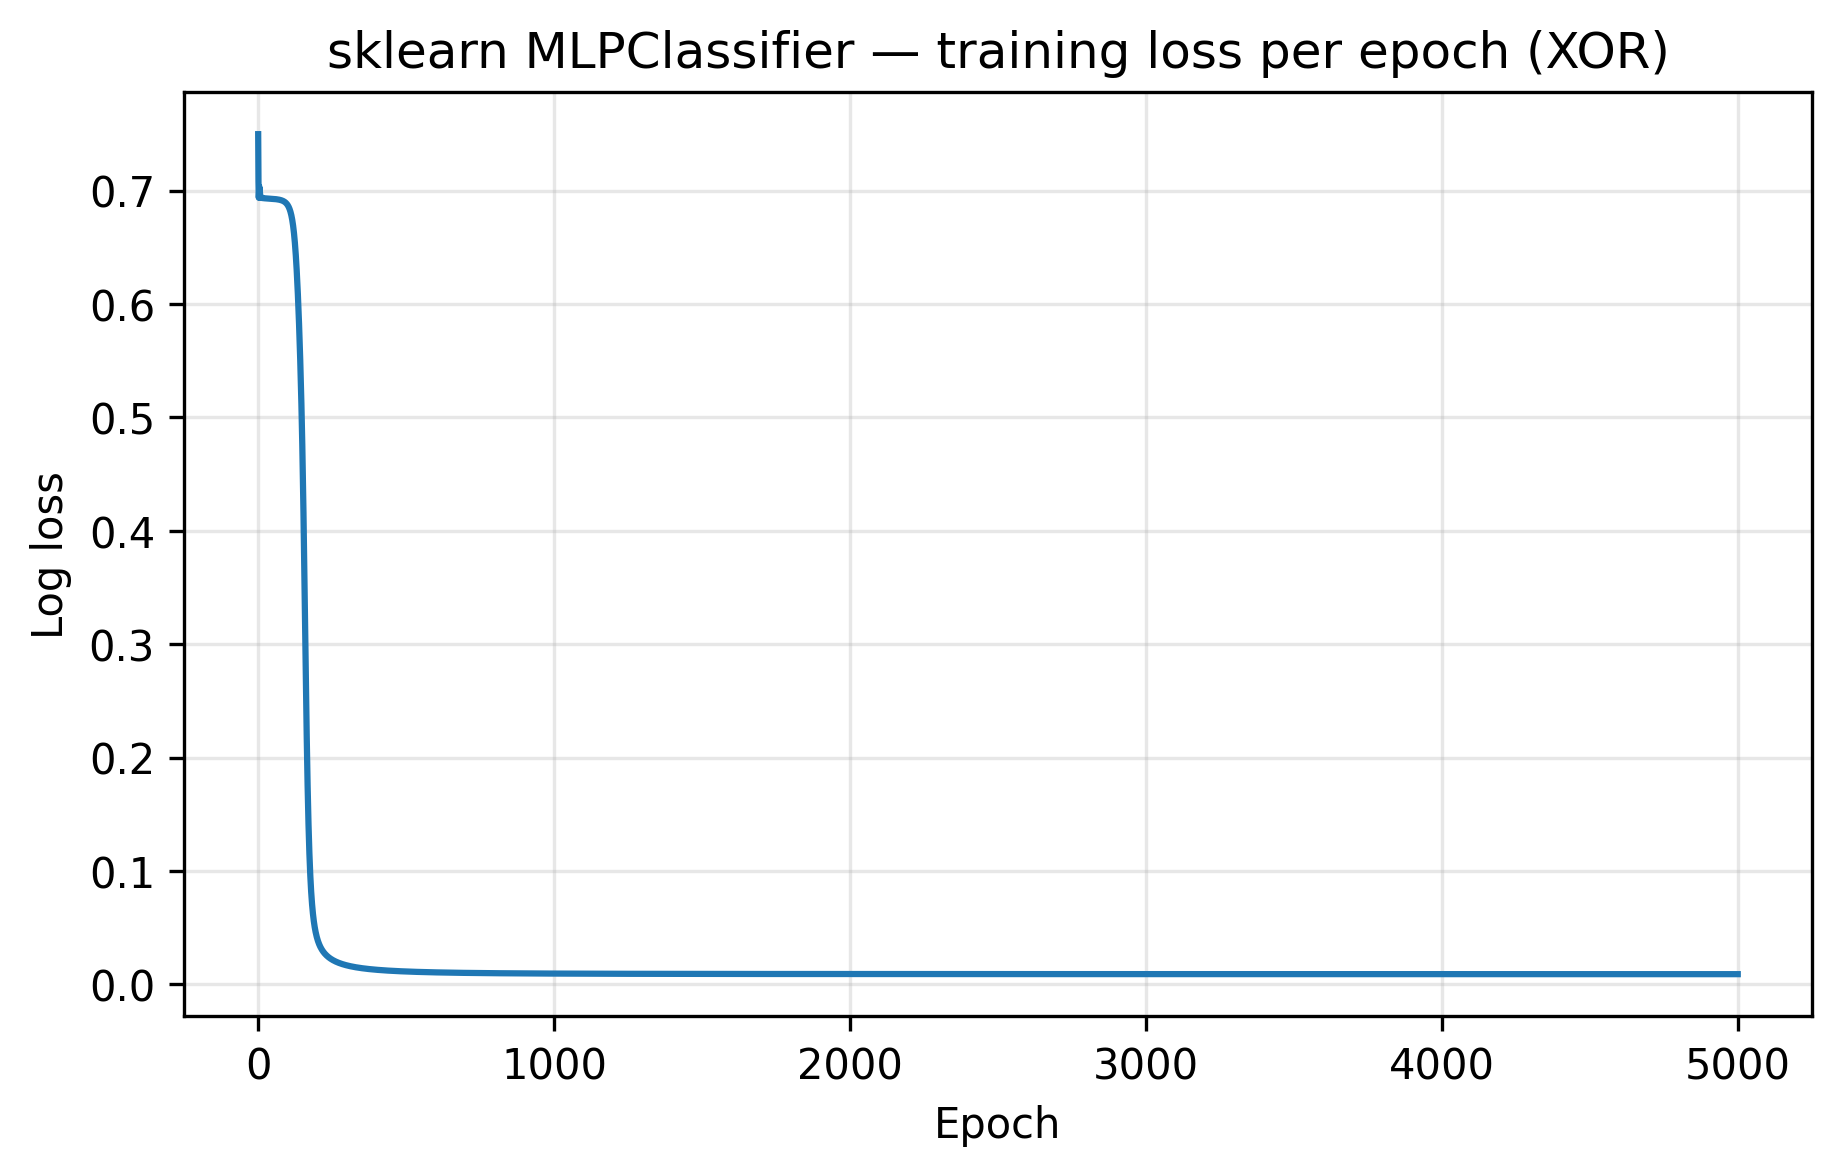

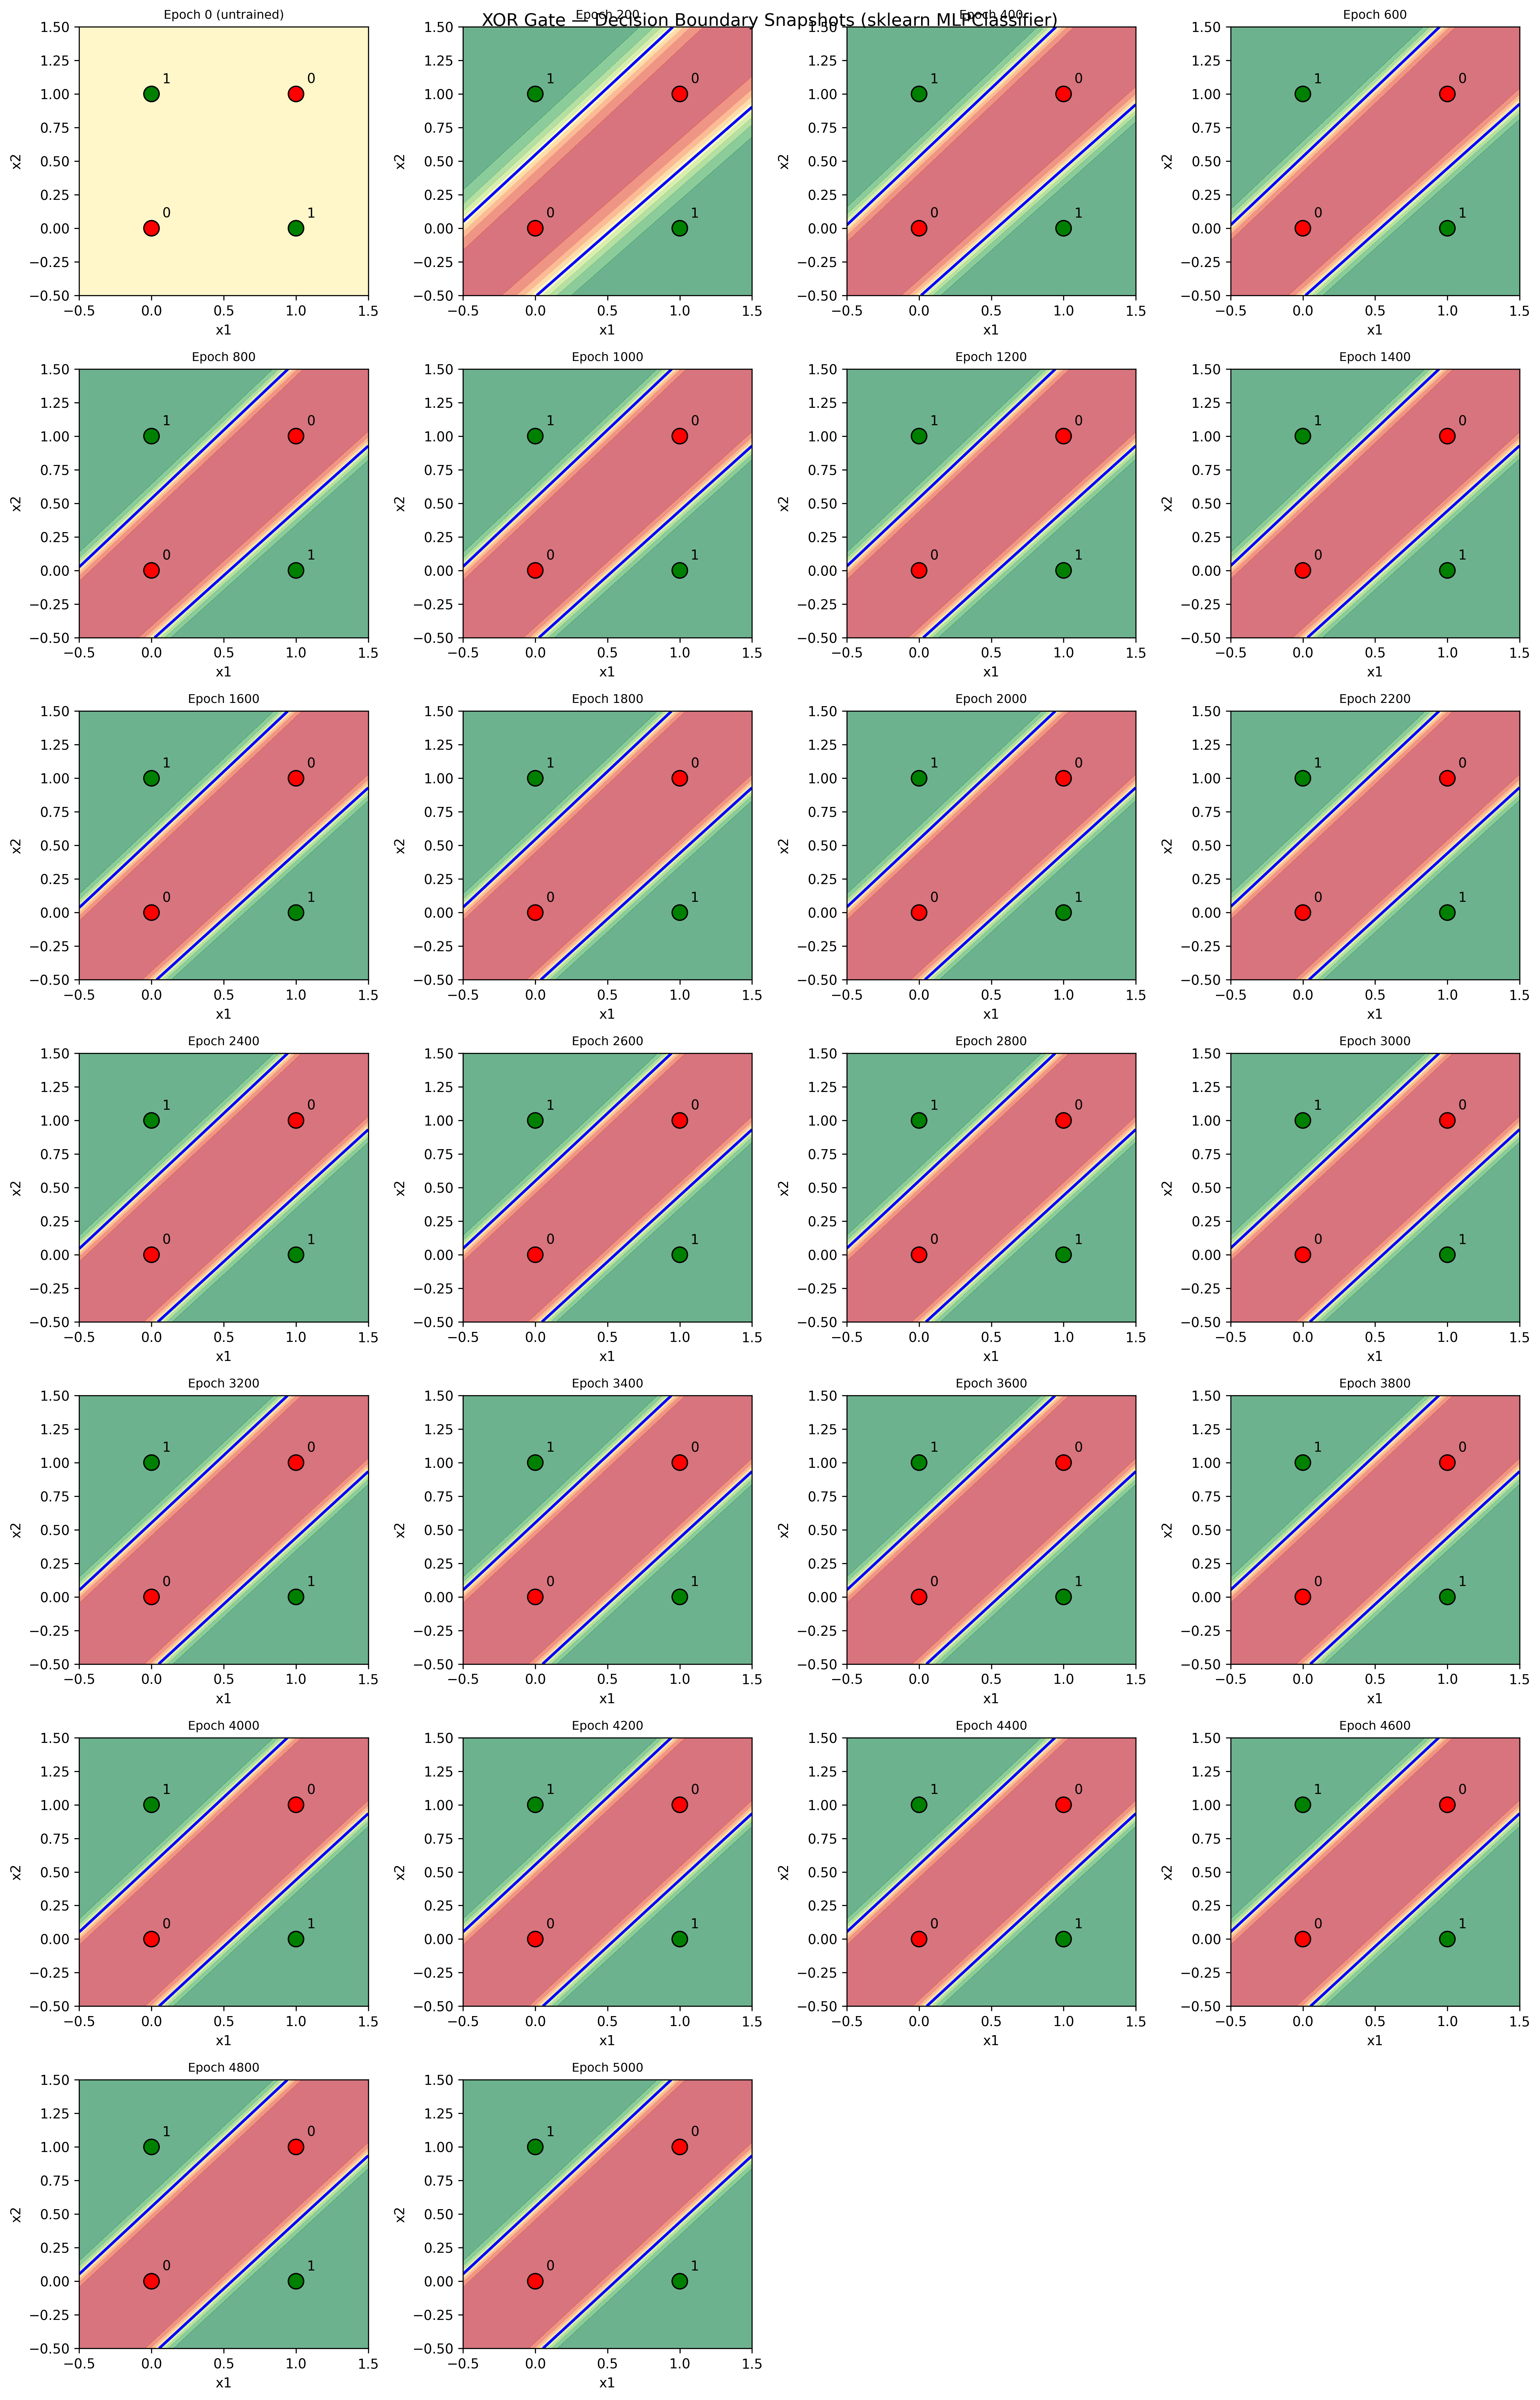

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history_sklearn)
plt.xlabel('Epoch'); plt.ylabel('Log loss')
plt.title('sklearn MLPClassifier — training loss per epoch (XOR)')
plt.grid(alpha=0.3)
plt.show()

plot_mlp_snapshots(snapshots_sklearn, gate_name='XOR', source_name='sklearn MLPClassifier')

--- Final predictions on XOR ---
Manual MLP  : [0 1 1 0]  (target: [0 1 1 0] )
Sklearn MLP : [0 1 1 0]  (target: [0 1 1 0] )

--- Final training loss ---
Manual MLP  final loss (MSE)     : 0.00054
Sklearn MLP final loss (log-loss): 0.00892



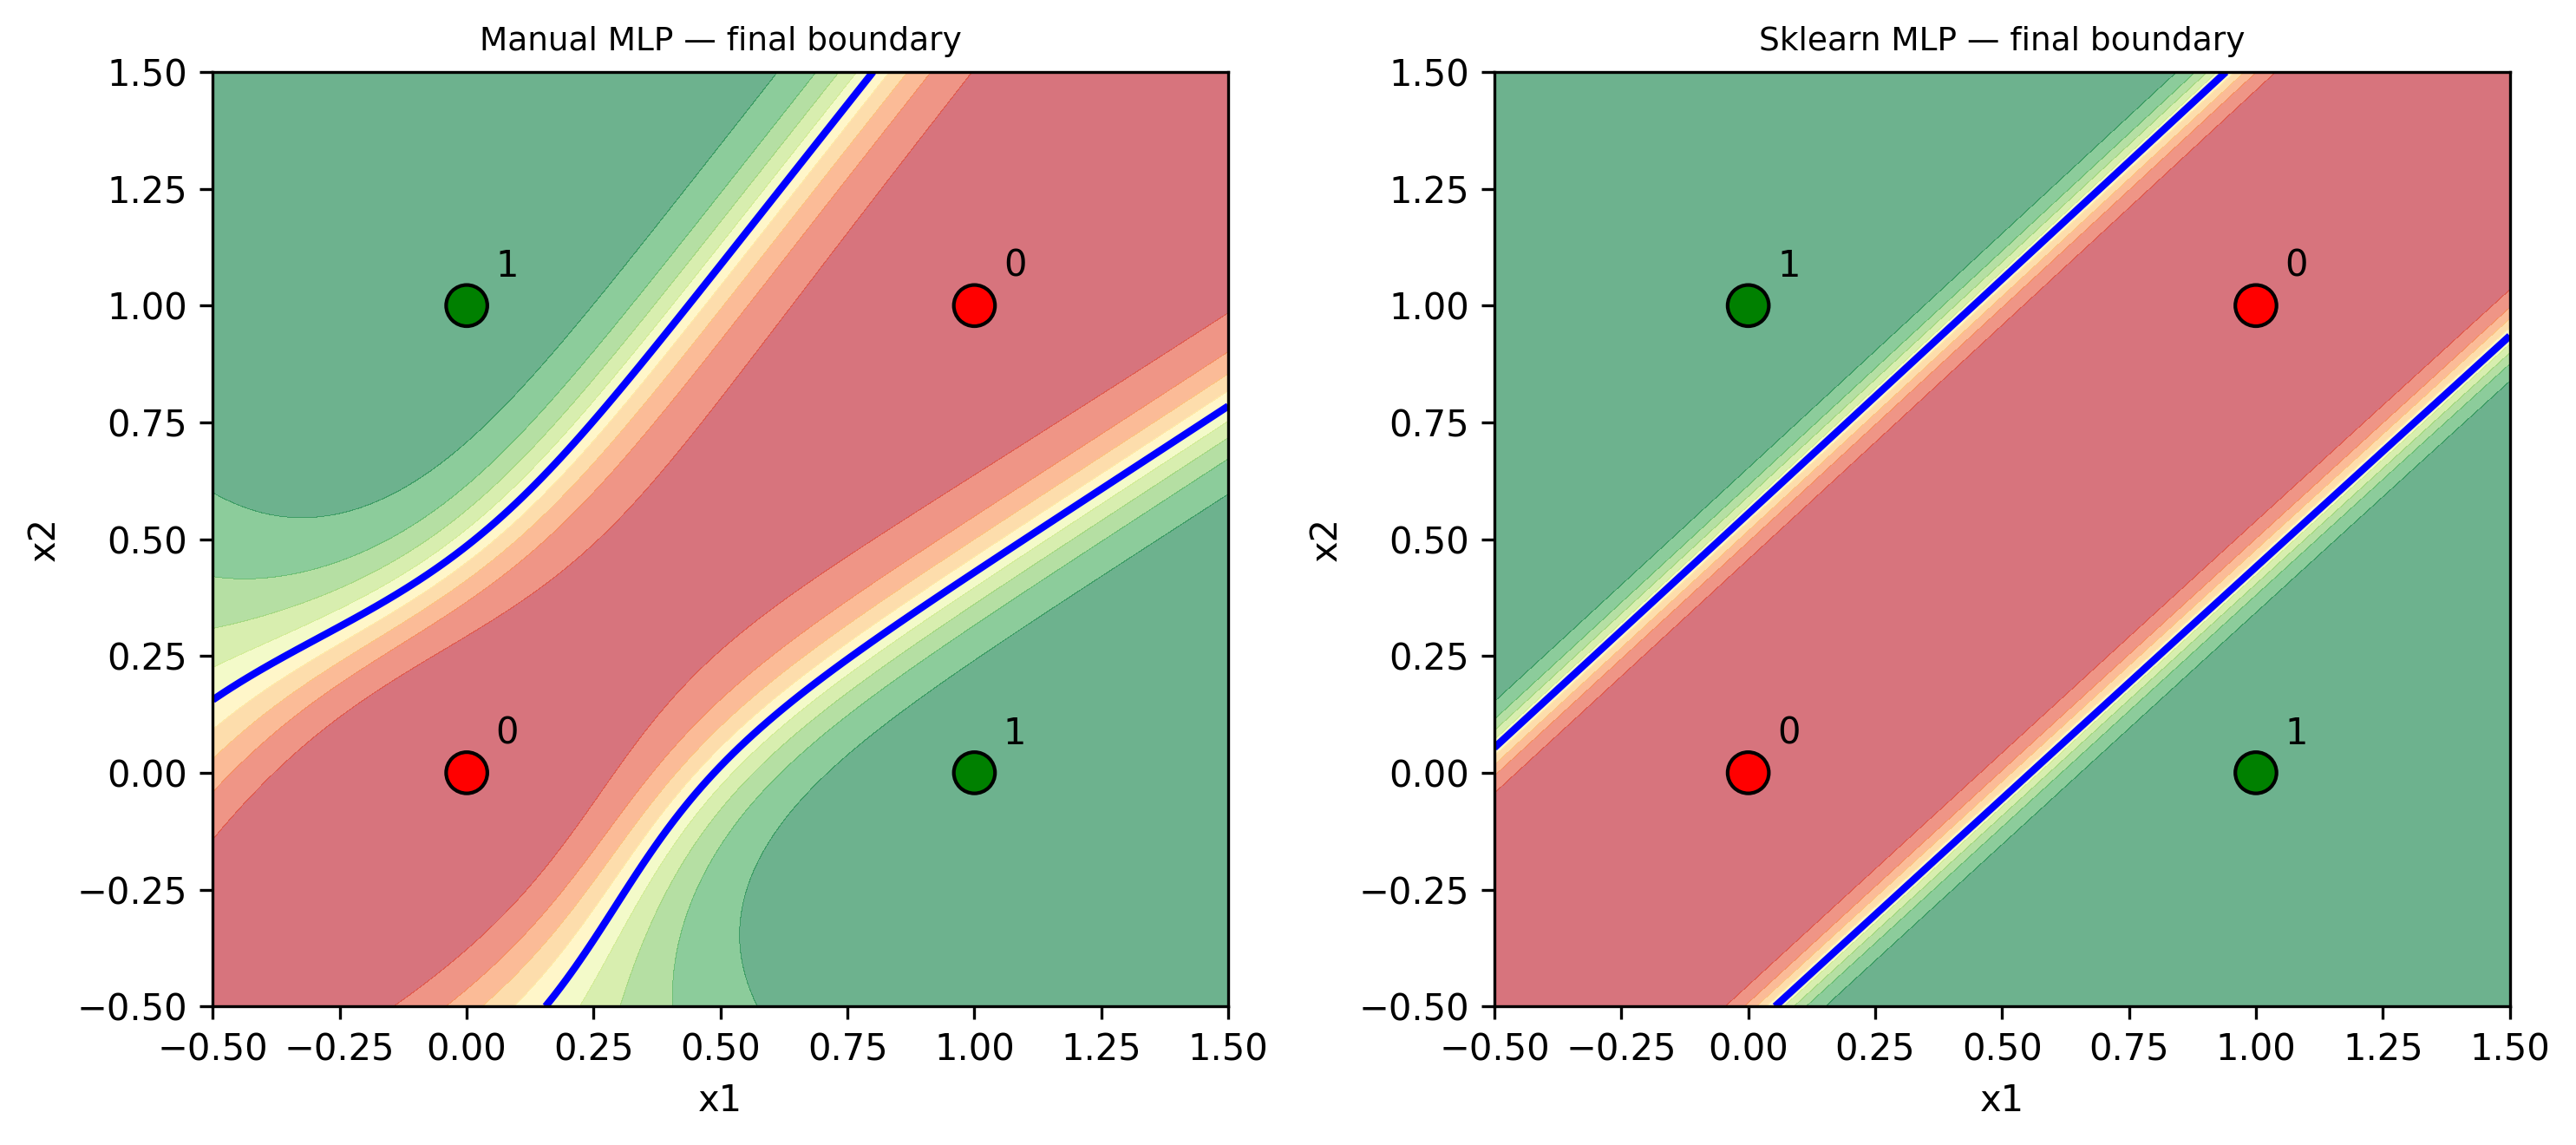

In [ ]:
print('--- Final predictions on XOR ---')
print('Manual MLP  :', final_preds_manual, ' (target:', y, ')')
print('Sklearn MLP :', final_preds_sklearn, ' (target:', y, ')')
print()
print('--- Final training loss ---')
print('Manual MLP  final loss (MSE)     :', round(loss_history_manual[-1], 5))
print('Sklearn MLP final loss (log-loss):', round(loss_history_sklearn[-1], 5))
print()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
plot_mlp_boundary(make_predict_fn(W1, b1, W2, b2), X, y, axes[0], 'Manual MLP — final boundary')
plot_mlp_boundary(lambda pts: clf.predict_proba(pts)[:, 1], X, y, axes[1], 'Sklearn MLP — final boundary')
plt.tight_layout()
plt.show()